# 🚢 Titanic — Complete Supervised ML Pipeline
### From Raw Data → Production-Grade Models

| Phase | Topic | Concepts Covered |
|-------|-------|-----------------|
| 1 | Data Understanding | EDA, describe(), MCAR/MAR/MNAR, distributions |
| 2 | Feature Engineering | Title extraction, FamilyBin, HasCabin, log1p, imputation |
| 3 | Baseline Modeling | Logistic Regression, coefficients, multicollinearity |
| 4 | Algorithm Comparison | LR, DT, RF, SVM, KNN, XGBoost — 5-fold CV |
| 5 | Learning Curves | Bias-variance diagnosis, gap analysis |
| 6 | Hyperparameter Tuning | GridSearchCV coarse→fine, RandomizedSearchCV |
| 7 | Production Pipelines | sklearn Pipeline, custom Transformers, .pkl export |
| 8 | Model Explainability | SHAP values, force plots, feature importance |
| 9 | Experiment Tracking | MLflow runs, metrics, artifact logging |

> **Dataset**: Titanic passenger survival (binary classification)  
> **Target**: `Survived` (0 = died, 1 = survived)  
> **Evaluation**: Accuracy, AUC-ROC, F1, Precision, Recall

---
# ⚙️ Setup & Imports

In [1]:
!pip install --upgrade shap xgboost lightgbm

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 18.3 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 60.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 56.6 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━

In [2]:
!pip install --upgrade cloudpickle dill

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.1
    Uninstalling cloudpickle-3.1.1:
      Successfully uninstalled cloudpickle-3.1.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cloudpickle]


In [3]:
! pip install shap

In [6]:
!pip install scikit-learn

In [7]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [13]:
!pip install mlflow

In [10]:
!pip install joblib


In [14]:
!pip install --upgrade typing_extensions

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

# ML — Core
from sklearn.model_selection import (train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# ML — Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# ML — Metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay)

# Explainability & Tracking
import shap
import mlflow
import mlflow.sklearn
import joblib

# Plot style
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.05)
plt.rcParams.update({'figure.dpi':100, 'figure.facecolor':'white'})
SEED = 42
np.random.seed(SEED)

DATA_PATH   = Path('../../practice/datasets/kaggle/titanic/train.csv')
MODEL_DIR   = Path('../models'); MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR  = Path('../outputs'); OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ All imports successful")
print(f"   scikit-learn: {__import__('sklearn').__version__}")
print(f"   XGBoost     : {__import__('xgboost').__version__}")
print(f"   SHAP        : {shap.__version__}")
print(f"   MLflow      : {mlflow.__version__}")

✅ All imports successful
   scikit-learn: 1.8.0
   XGBoost     : 3.2.0
   SHAP        : 0.51.0
   MLflow      : 3.11.1


---
# Phase 1 — Data Understanding & EDA

## 📘 Theory: Why EDA Comes First

> Before touching any model, we must deeply understand the data.
> EDA answers three questions:
>
> 1. **What is the data?** — Shape, dtypes, value ranges
> 2. **What is missing or wrong?** — Null patterns, impossible values
> 3. **What patterns exist?** — Distributions, correlations, target leakage
>
> Skipping EDA is the #1 cause of production ML failures.

In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
# ── Load ────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(8)

Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [10]:
# ── 1.1  Data types & basic statistics ─────────────────────────────────────
print("=" * 65)
print("COLUMN INFO")
print("=" * 65)
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.count(),
    'null_pct': (df.isnull().mean()*100).round(1),
    'unique'  : df.nunique(),
    'sample'  : [df[c].dropna().iloc[0] if df[c].count()>0 else None for c in df.columns]
})
print(info_df.to_string())

COLUMN INFO
               dtype  non_null  null_pct  unique                   sample
PassengerId    int64       891       0.0     891                        1
Survived       int64       891       0.0       2                        0
Pclass         int64       891       0.0       3                        3
Name          object       891       0.0     891  Braund, Mr. Owen Harris
Sex           object       891       0.0       2                     male
Age          float64       714      19.9      88                     22.0
SibSp          int64       891       0.0       7                        1
Parch          int64       891       0.0       7                        0
Ticket        object       891       0.0     681                A/5 21171
Fare         float64       891       0.0     248                     7.25
Cabin         object       204      77.1     147                      C85
Embarked      object       889       0.2       3                        S


## 📘 Theory: Reading df.describe()

> `df.describe()` gives 8 statistics for each numeric column.  
> Here is what each tells you:
>
> | Stat | Meaning | Red Flag |
> |------|---------|----------|
> | `count` | Non-null values | count < len(df) → missing data |
> | `mean` | Average | far from median → skewed/outliers |
> | `std` | Spread | large std → high variance feature |
> | `min` / `max` | Range | impossible values (age=-1, fare=0) |
> | `25%`/`75%` | IQR boundaries | IQR used for outlier detection |
> | `50%` | Median | mean≠median → non-normal distribution |

In [12]:
# ── 1.2  Extended describe with skew + kurtosis ─────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.drop(['PassengerId','Survived'])
desc = df[num_cols].describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T
desc['skew']     = df[num_cols].skew().round(3)
desc['kurtosis'] = df[num_cols].kurtosis().round(3)
desc['cv']       = (df[num_cols].std() / df[num_cols].mean()).round(3)  # Coefficient of Variation

print("Extended Numeric Summary:")
print(desc.round(2).to_string())
print()
print("Skew interpretation: |skew| < 0.5 = symmetric | 0.5–1 = moderate | >1 = high")

Extended Numeric Summary:
        count   mean    std   min   1%    5%    25%    50%   75%     95%     99%     max  skew  kurtosis    cv
Pclass  891.0   2.31   0.84  1.00  1.0  1.00   2.00   3.00   3.0    3.00    3.00    3.00 -0.63     -1.28  0.36
Age     714.0  29.70  14.53  0.42  1.0  4.00  20.12  28.00  38.0   56.00   65.87   80.00  0.39      0.18  0.49
SibSp   891.0   0.52   1.10  0.00  0.0  0.00   0.00   0.00   1.0    3.00    5.00    8.00  3.70     17.88  2.11
Parch   891.0   0.38   0.81  0.00  0.0  0.00   0.00   0.00   0.0    2.00    4.00    6.00  2.75      9.78  2.11
Fare    891.0  32.20  49.69  0.00  0.0  7.22   7.91  14.45  31.0  112.08  249.01  512.33  4.79     33.40  1.54

Skew interpretation: |skew| < 0.5 = symmetric | 0.5–1 = moderate | >1 = high


## 📘 Theory: Missing Value Taxonomy (MCAR / MAR / MNAR)

> Understanding **WHY** data is missing determines HOW to handle it.
>
> | Type | Full Name | Meaning | Example | Treatment |
> |------|-----------|---------|---------|-----------|
> | **MCAR** | Missing Completely At Random | No pattern; random dropout | Sensor glitch | Mean/median imputation safe |
> | **MAR** | Missing At Random | Depends on *observed* variables | Age missing more for 3rd class | Group-based imputation |
> | **MNAR** | Missing Not At Random | Depends on the *missing value itself* | High earners skip income | Binary flag + impute |
>
> **Titanic-specific:**
> - `Age` → MAR (missing more in Pclass 3 → impute by Pclass+Sex group median)
> - `Cabin` → MNAR (only wealthy recorded cabin; absence carries signal → `HasCabin` flag)
> - `Embarked` → MCAR (2 random nulls → safe to impute with mode)

In [14]:
# ── 1.3  Missing Value Analysis ──────────────────────────────────────────────
print("MISSING VALUE ANALYSIS")
print("=" * 60)
miss = pd.DataFrame({
    'n_miss' : df.isnull().sum(),
    'pct'    : (df.isnull().mean()*100).round(2)
}).query('n_miss > 0').sort_values('pct', ascending=False)

for col, row in miss.iterrows():
    if col == 'Cabin':
        mtype = 'MNAR  → create HasCabin binary flag (absence = signal)'
    elif col == 'Age':
        # Check if missingness correlates with Pclass
        corr = df['Age'].isnull().corr(df['Pclass'])
        mtype = f'MAR   → correlates with Pclass (r={corr:.3f}) → group-median impute'
    else:
        mtype = 'MCAR  → random (n=2) → safe to fill with mode'
    print(f"  {col:<12}  {row['n_miss']:4d} missing  ({row['pct']:5.1f}%)  →  {mtype}")

# Visualise missing pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
miss_matrix = df[miss.index].isnull().astype(int)
sns.heatmap(miss_matrix.T, cbar=False, yticklabels=True,
            cmap=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Missing Pattern (red = null)', fontweight='bold')
axes[0].set_xlabel('Passenger index')

# Bar chart
miss['pct'].plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#3498db'])
axes[1].set_title('% Missing per Column', fontweight='bold')
axes[1].set_ylabel('% Missing')
axes[1].axhline(5,  color='orange', ls='--', label='5% threshold')
axes[1].axhline(20, color='red',    ls='--', label='20% threshold')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_missing_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/p1_missing_analysis.png")

MISSING VALUE ANALYSIS


ValueError: Unknown format code 'd' for object of type 'float'

## 📊 Survival Rate Analysis Across All Features

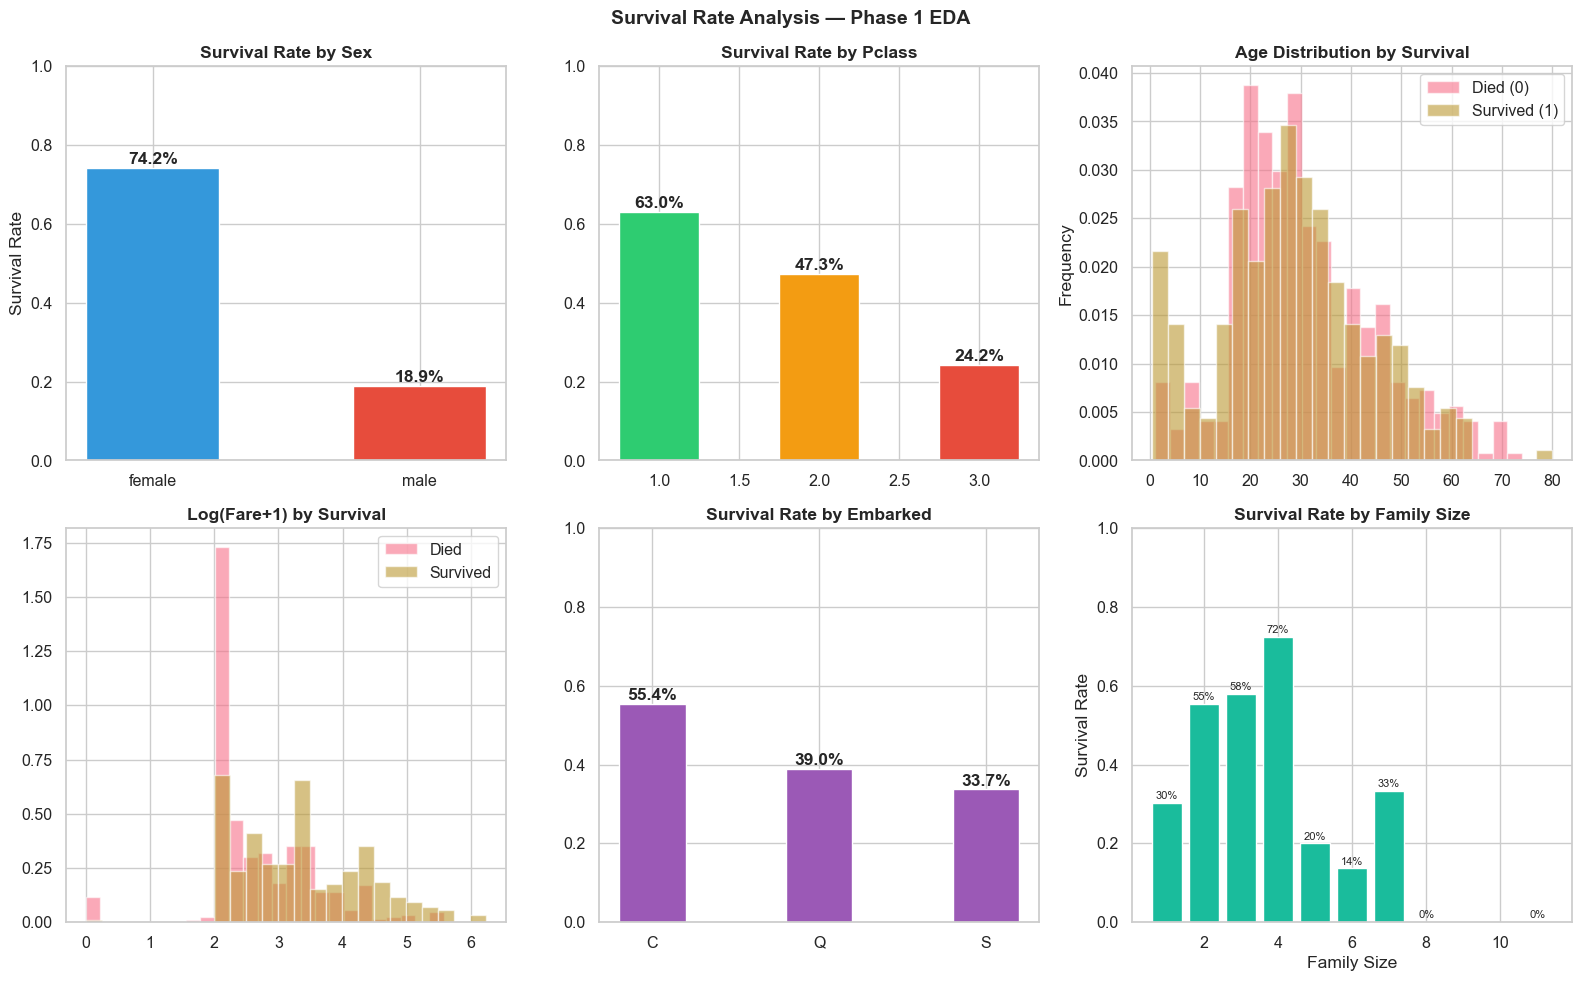

In [13]:
# ── 1.4  Survival rate by every feature ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Survival Rate Analysis — Phase 1 EDA', fontsize=14, fontweight='bold')

# (A) By Sex
surv_sex = df.groupby('Sex')['Survived'].mean()
axes[0,0].bar(surv_sex.index, surv_sex.values,
              color=['#3498db','#e74c3c'], edgecolor='white', width=0.5)
axes[0,0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
for i,(k,v) in enumerate(surv_sex.items()):
    axes[0,0].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0,0].set_ylim(0,1)

# (B) By Pclass
surv_pc = df.groupby('Pclass')['Survived'].mean()
colors  = ['#2ecc71','#f39c12','#e74c3c']
axes[0,1].bar(surv_pc.index, surv_pc.values, color=colors, edgecolor='white', width=0.5)
axes[0,1].set_title('Survival Rate by Pclass', fontweight='bold')
for i,(k,v) in enumerate(surv_pc.items()):
    axes[0,1].text(k, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0,1].set_ylim(0,1)

# (C) Age distribution by survival
df.dropna(subset=['Age']).groupby('Survived')['Age'].plot(
    kind='hist', bins=25, alpha=0.6, density=True, ax=axes[0,2])
axes[0,2].set_title('Age Distribution by Survival', fontweight='bold')
axes[0,2].legend(['Died (0)','Survived (1)'])

# (D) Fare distribution (log scale) by survival
for cls in [0,1]:
    vals = np.log1p(df[df['Survived']==cls]['Fare'].dropna())
    axes[1,0].hist(vals, bins=25, alpha=0.6, density=True, label=f'{"Survived" if cls else "Died"}')
axes[1,0].set_title('Log(Fare+1) by Survival', fontweight='bold')
axes[1,0].legend()

# (E) Embarked survival
surv_emb = df.groupby('Embarked')['Survived'].mean().dropna()
axes[1,1].bar(surv_emb.index, surv_emb.values, color='#9b59b6', edgecolor='white', width=0.4)
axes[1,1].set_title('Survival Rate by Embarked', fontweight='bold')
for i,(k,v) in enumerate(surv_emb.items()):
    axes[1,1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[1,1].set_ylim(0,1)

# (F) SibSp+Parch survival heatmap
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
pivot = df.groupby('FamilySize')['Survived'].agg(['mean','count'])
pivot.columns = ['SurvRate','Count']
axes[1,2].bar(pivot.index, pivot['SurvRate'], color='#1abc9c', edgecolor='white')
axes[1,2].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1,2].set_xlabel('Family Size')
axes[1,2].set_ylabel('Survival Rate')
axes[1,2].set_ylim(0,1)
for i, row in pivot.iterrows():
    axes[1,2].text(i, row['SurvRate']+0.01, f'{row["SurvRate"]:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_survival_analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 1.5  Correlation heatmap ─────────────────────────────────────────────────
num_for_corr = ['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']
corr_matrix  = df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Feature Correlation Heatmap\n(lower triangle only — avoids redundancy)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_correlation.png', bbox_inches='tight')
plt.show()

print("Key correlations with Survived:")
print(corr_matrix['Survived'].sort_values(ascending=False).to_string())

---
# Phase 2 — Feature Engineering

## 📘 Theory: Feature Engineering Principles

> Feature engineering is the process of using domain knowledge to transform
> raw variables into representations that better capture signal for the model.
>
> **The 5 FE patterns covered here:**
>
> | Pattern | Example | Benefit |
> |---------|---------|---------|
> | **Extraction** | `Title` from `Name` | Encode domain knowledge (gender+status) |
> | **Binning (non-linear)** | `FamilyBin` from `FamilySize` | Capture U-shaped relationship |
> | **Binary Flag from MNAR** | `HasCabin` from `Cabin` | Missing-ness IS the signal |
> | **Log Transform** | `log1p(Fare)` | Reduce right-skew, stabilise variance |
> | **Group Imputation** | Age by Pclass+Sex median | Smarter than global mean |
>
> 🏭 **Industry Note**: Feature engineering typically accounts for 60–80% of
> model performance improvement — far more than algorithm choice.

In [ ]:
# ── 2.1  Title Extraction ────────────────────────────────────────────────────
def extract_title(name):
    """Extract title from 'Lastname, Title. Firstname' format."""
    import re
    match = re.search(r',\s*([^.]+)\.', str(name))
    if match:
        title = match.group(1).strip()
        rare  = {'Don','Rev','Dr','Major','Lady','Sir','Col','Capt',
                 'Countess','Jonkheer','Mme','Ms','Mlle'}
        if title in rare: return 'Rare'
        return title
    return 'Unknown'

df['Title'] = df['Name'].apply(extract_title)
print("Title distribution:")
print(df['Title'].value_counts().to_string())
print()
print("Survival rate by Title:")
print(df.groupby('Title')['Survived'].agg(['mean','count']).round(3).to_string())

In [ ]:
# ── 2.2  FamilySize → non-linear FamilyBin ──────────────────────────────────
# FamilySize already created in Phase 1
# The survival curve is U-shaped: alone=bad, small=good, large=bad
def family_bin(size):
    if size == 1: return 'Alone'
    if size <= 4: return 'Small'
    return 'Large'

df['FamilyBin'] = df['FamilySize'].apply(family_bin)

# Validate the non-linearity
print("Survival by FamilyBin:")
fb_surv = df.groupby('FamilyBin')['Survived'].agg(['mean','count'])
print(fb_surv)
print()
print("WHY non-linear binning? — if we kept FamilySize as numeric,")
print("linear models assume monotone relationship, missing the peak at size 2-4")

In [ ]:
# ── 2.3  HasCabin — MNAR Binary Flag ────────────────────────────────────────
df['HasCabin'] = df['Cabin'].notna().astype(int)
print("HasCabin survival comparison:")
print(df.groupby('HasCabin')['Survived'].agg(['mean','count']).rename(
    index={0:'No Cabin (MNAR)', 1:'Has Cabin'}))
print()
print("If we just dropped Cabin, we'd lose this ~15pp survival signal.")

In [ ]:
# ── 2.4  Fare: Log1p Transform ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fare Transformation Analysis', fontweight='bold')

# Raw
axes[0].hist(df['Fare'].dropna(), bins=50, color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0].set_title(f'Raw Fare\nSkew = {df["Fare"].skew():.3f}', fontweight='bold')
axes[0].set_xlabel('Fare (£)')

# Log1p
df['Fare_log'] = np.log1p(df['Fare'])
axes[1].hist(df['Fare_log'].dropna(), bins=50, color='#2ecc71', edgecolor='none', alpha=0.8)
axes[1].set_title(f'log1p(Fare)\nSkew = {df["Fare_log"].skew():.3f}', fontweight='bold')
axes[1].set_xlabel('log(Fare + 1)')

# QQ plot of log-transformed
stats.probplot(df['Fare_log'].dropna(), plot=axes[2])
axes[2].set_title('Q-Q Plot: log1p(Fare) vs Normal', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p2_fare_transform.png', bbox_inches='tight')
plt.show()
print(f"Skew before: {df['Fare'].skew():.3f}  →  after log1p: {df['Fare_log'].skew():.3f}")

## 📘 Theory: Why log1p and not log?

> - `np.log(0)` = **-infinity** → crashes if any Fare = 0
> - `np.log1p(x)` = `log(x + 1)` → safe for zero values
> - Also numerically stable for very small values
> - After transform: model sees roughly equal spacing between fare bands
> - **Industry rule**: Apply to any feature with skew > 1.0

In [ ]:
# ── 2.5  Age Imputation — Group Median by Pclass + Sex ───────────────────────
print("Why group-median over global median?")
print()
print("Age median by Pclass × Sex group:")
age_medians = df.groupby(['Pclass','Sex'])['Age'].median().round(1)
print(age_medians.to_string())

print()
global_med = df['Age'].median()
print(f"Global median: {global_med:.1f}")
print()
print("A 1st-class woman has very different expected age than a 3rd-class boy.")
print("Using global median ignores this — group median is far more accurate.")

# Impute
df['Age_imputed'] = df.groupby(['Pclass','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))

print(f"\nMissing Age before: {df['Age'].isnull().sum()}")
print(f"Missing Age after:  {df['Age_imputed'].isnull().sum()}")

In [ ]:
# ── 2.6  Final Feature Assembly ──────────────────────────────────────────────
df['Embarked_filled'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['IsCrew']          = (df['Fare'] == 0).astype(int)

# One-hot encode
df_eng = pd.get_dummies(df[[
    'Survived','Pclass','Sex','Age_imputed','SibSp','Parch',
    'Fare_log','HasCabin','IsCrew','FamilySize','FamilyBin',
    'Title','Embarked_filled'
]], columns=['Sex','FamilyBin','Title','Embarked_filled'], drop_first=False)

# Drop one dummy per group to avoid multicollinearity
cols_to_drop = [c for c in df_eng.columns if c.endswith('_male') or
                c.endswith('_Alone') or c.endswith('_Mr.') or c.endswith('_S')]
df_eng.drop(columns=[c for c in cols_to_drop if c in df_eng.columns], inplace=True)

print(f"Feature matrix shape: {df_eng.shape}")
print(f"\nFeatures ({df_eng.shape[1]-1} predictors):")
feat_cols = [c for c in df_eng.columns if c != 'Survived']
for i, f in enumerate(feat_cols, 1):
    print(f"  {i:2d}. {f}")

In [ ]:
# ── 2.7  Train / Test Split (stratified) ────────────────────────────────────
X = df_eng.drop('Survived', axis=1)
y = df_eng['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train survival rate: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")
print("\nStratified split ensures train/test have same class proportions ✅")

---
# Phase 3 — Baseline Modeling: Logistic Regression

## 📘 Theory: Logistic Regression as a Baseline

> **Always start with the simplest interpretable model.**
> Logistic Regression gives you:
>
> 1. A performance **floor** — every other model must beat this
> 2. **Coefficient interpretation** — which features matter and in what direction
> 3. **Multicollinearity detection** — sign flips, unexpected coefficients
> 4. Fast training → quick iteration cycle
>
> The logistic function: `P(y=1) = 1 / (1 + e^(-z))` where `z = β₀ + β₁x₁ + ...`
>
> **Coefficient interpretation:**
> - Positive β → feature increases P(survive)
> - |β| = magnitude of effect (after standardisation)
> - Sign flip from EDA expectation → multicollinearity warning

In [ ]:
# ── 3.1  Logistic Regression Baseline ───────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_train_s, y_train)

y_pred   = lr.predict(X_test_s)
y_proba  = lr.predict_proba(X_test_s)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"{'='*45}")
print(f"  LOGISTIC REGRESSION — BASELINE RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*45}")
print()
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

In [ ]:
# ── 3.2  Coefficient Interpretation + Multicollinearity Lesson ──────────────
coef_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (Standardized)\n'
             'Green = increases survival probability | Red = decreases',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')

# Annotate key ones
for _, row in coef_df.head(5).iterrows():
    ax.text(row['coefficient'] + 0.01, row['feature'],
            f'{row["coefficient"]:+.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p3_lr_coefficients.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most influential features (by |coefficient|):")
print(coef_df.head(5).to_string(index=False))
print()
print("⚠️  Industry Note: Sex and Title features are correlated.")
print("   This causes the Sex coefficient to appear unexpectedly small —")
print("   Title (Mr/Mrs/Miss) already encodes gender implicitly.")
print("   This is multicollinearity — always check when coefficients surprise you.")

In [ ]:
# ── 3.3  ROC Curve + Confusion Matrix ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'LR Baseline (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression Baseline', fontweight='bold')
axes[0].legend(loc='lower right')

# Optimal threshold by Youden's J
youden_j = tpr - fpr
opt_idx  = np.argmax(youden_j)
opt_thr  = thresholds[opt_idx]
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=80, color='red',
                zorder=5, label=f'Optimal threshold = {opt_thr:.2f}')
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Died','Survived'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix (threshold=0.5)\nAcc={acc:.3f}  F1={f1:.3f}',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p3_roc_confusion.png', bbox_inches='tight')
plt.show()
print(f"Optimal threshold (Youden's J): {opt_thr:.3f}")
print(f"At 0.5 threshold: {confusion_matrix(y_test,y_pred)[0,1]} false alarms, {confusion_matrix(y_test,y_pred)[1,0]} missed survivors")

---
# Phase 4 — Algorithm Comparison (6 Models, 5-Fold CV)

## 📘 Theory: Algorithm Comparison Framework

> We compare 6 algorithms spanning the key ML families:
>
> | Algorithm | Family | Key Characteristic | Hyperparams to tune |
> |-----------|--------|-------------------|---------------------|
> | Logistic Regression | Linear | Fast, interpretable, needs scaling | C, penalty |
> | Decision Tree | Tree | Interpretable, prone to overfit | max_depth, min_samples |
> | Random Forest | Ensemble (Bagging) | Reduces variance, robust | n_estimators, max_depth |
> | SVM | Kernel | Excellent in high-dim, needs scaling | C, kernel, gamma |
> | KNN | Instance-based | No training, needs scaling | k, weights, metric |
> | XGBoost | Ensemble (Boosting) | State-of-art tabular data | lr, depth, subsample |
>
> **Why 5-fold CV and not a single train/test split?**
> A single split is subject to random variation. 5-fold CV trains 5 models,
> each tested on a different 20% held-out fold — giving a stable, low-variance
> estimate of generalisation performance.

In [ ]:
# ── 4.1  Define all 6 algorithms ─────────────────────────────────────────────
algorithms = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'      : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'SVM'                : SVC(probability=True, random_state=SEED),
    'KNN'                : KNeighborsClassifier(),
    'XGBoost'            : XGBClassifier(random_state=SEED, eval_metric='logloss',
                                          verbosity=0, n_jobs=-1),
}

# Algorithms needing scaling
needs_scale = {'Logistic Regression', 'SVM', 'KNN'}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("Running 5-fold cross-validation on all 6 algorithms...")
print("(This may take 30–60 seconds)")

In [ ]:
# ── 4.2  Run CV comparison ───────────────────────────────────────────────────
results = {}
for name, model in algorithms.items():
    if name in needs_scale:
        from sklearn.pipeline import make_pipeline
        pipe = make_pipeline(StandardScaler(), model)
    else:
        pipe = model

    # Multiple metrics via cross_val_score
    acc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='f1', n_jobs=-1)

    results[name] = {
        'acc_mean' : acc_scores.mean(), 'acc_std': acc_scores.std(),
        'auc_mean' : auc_scores.mean(), 'auc_std': auc_scores.std(),
        'f1_mean'  : f1_scores.mean(),  'f1_std' : f1_scores.std(),
    }
    print(f"  {name:<22}  Acc={acc_scores.mean():.4f}±{acc_scores.std():.4f}  "
          f"AUC={auc_scores.mean():.4f}  F1={f1_scores.mean():.4f}")

results_df = pd.DataFrame(results).T
print("\n5-Fold CV Results Summary:")
print(results_df[['acc_mean','auc_mean','f1_mean','acc_std']].round(4).sort_values('auc_mean',ascending=False).to_string())

In [ ]:
# ── 4.3  Comparison Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Algorithm Comparison — 5-Fold CV (Train Set)', fontsize=14, fontweight='bold')

metrics = [('acc_mean','acc_std','Accuracy'), ('auc_mean','auc_std','AUC-ROC'), ('f1_mean','f1_std','F1-Score')]
palette = sns.color_palette('husl', len(results_df))

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    sorted_df = results_df.sort_values(mean_col, ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df[mean_col], 
                   xerr=sorted_df[std_col], capsize=4,
                   color=palette, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(sorted_df[mean_col].min() - 0.05, 1.0)
    ax.axvline(results_df.loc['Logistic Regression',mean_col], 
               color='red', ls='--', lw=1, alpha=0.5, label='LR baseline')
    for bar, val in zip(bars, sorted_df[mean_col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p4_algorithm_comparison.png', bbox_inches='tight')
plt.show()

---
# Phase 5 — Learning Curves & Bias-Variance Diagnosis

## 📘 Theory: Learning Curves & the Bias-Variance Trade-off

> A **learning curve** plots model performance as training size increases.
> The gap between train and validation score diagnoses the problem:
>
> ```
> HIGH BIAS (Underfitting)         HIGH VARIANCE (Overfitting)
> ─────────────────────────         ─────────────────────────
> Train  score: LOW  (e.g. 0.75)   Train  score: HIGH (e.g. 0.98)
> Valid  score: LOW  (e.g. 0.74)   Valid  score: LOW  (e.g. 0.80)
> Gap         : tiny               Gap         : LARGE
> Converges   : both plateau low   Converges   : not yet converged
> Fix         : more features,     Fix         : more data, regularise,
>               complex model                  prune, dropout
> ```
>
> **Key insight**: If both curves converge to the same low value →
> more data won't help. You need a better model or more features.

In [ ]:
# ── 5.1  Learning curves for all 6 models ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Learning Curves — Bias-Variance Diagnosis (5-Fold CV)',
             fontsize=14, fontweight='bold')

train_sizes_abs = np.linspace(0.10, 1.0, 10)

for ax, (name, model) in zip(axes.flat, algorithms.items()):
    if name in needs_scale:
        from sklearn.pipeline import make_pipeline
        pipe = make_pipeline(StandardScaler(), model)
    else:
        pipe = model

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes_abs, cv=cv, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=SEED)

    t_mean, t_std = train_scores.mean(1), train_scores.std(1)
    v_mean, v_std = val_scores.mean(1), val_scores.std(1)

    ax.plot(train_sizes, t_mean, 'o-', color='#e74c3c', lw=2, ms=4, label='Train AUC')
    ax.plot(train_sizes, v_mean, 's-', color='#2980b9', lw=2, ms=4, label='CV Val AUC')
    ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='#e74c3c')
    ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='#2980b9')

    gap = t_mean[-1] - v_mean[-1]
    diagnosis = ('🔴 High Variance — reduce complexity' if gap > 0.10 else
                 '🟡 Slight Variance — light regularisation' if gap > 0.05 else
                 '🟢 Good Fit / At Ceiling')

    ax.set_title(f'{name}\nGap={gap:.3f}  {diagnosis}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.60, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p5_learning_curves.png', bbox_inches='tight')
plt.show()
print("Analysis complete — see titles for bias/variance diagnosis per model")

---
# Phase 6 — Hyperparameter Tuning

## 📘 Theory: GridSearchCV vs RandomizedSearchCV

> **GridSearchCV**: Exhaustive search over all combinations.
> - Guarantees finding the best in the grid
> - Expensive: 10 params × 5 folds × 5 values each = 250 fits
> - Best for: small grids, final fine-tuning
>
> **RandomizedSearchCV**: Samples n_iter combinations randomly.
> - Faster: you control cost with n_iter
> - Often finds 90%+ of GridSearch quality in 10% of time
> - Best for: large search spaces, initial exploration
>
> **Industry Strategy: Coarse → Fine**
> 1. RandomizedSearch over wide ranges → find promising region
> 2. GridSearch over narrow range around best → fine-tune
> 3. Re-fit on full train set with best params

In [ ]:
# ── 6.1  XGBoost — Coarse RandomizedSearch ──────────────────────────────────
print("XGBOOST TUNING — Phase 1: Coarse RandomizedSearchCV")
print("=" * 55)

xgb_coarse_grid = {
    'n_estimators'     : [50, 100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma'            : [0, 0.1, 0.2, 0.5, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'reg_alpha'        : [0, 0.01, 0.1, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

xgb_base = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1)
random_search = RandomizedSearchCV(
    xgb_base, xgb_coarse_grid, n_iter=60, cv=cv,
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0)
random_search.fit(X_train, y_train)

print(f"Best coarse AUC: {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")

In [ ]:
# ── 6.2  XGBoost — Fine GridSearchCV ─────────────────────────────────────────
print("XGBOOST TUNING — Phase 2: Fine GridSearchCV around best params")
best = random_search.best_params_

xgb_fine_grid = {
    'n_estimators'  : sorted(set([max(50, best['n_estimators']-50),
                                   best['n_estimators'],
                                   best['n_estimators']+50])),
    'max_depth'     : sorted(set([max(2, best['max_depth']-1),
                                   best['max_depth'],
                                   best['max_depth']+1])),
    'learning_rate' : sorted(set([max(0.01, best['learning_rate']*0.5),
                                   best['learning_rate'],
                                   best['learning_rate']*1.5])),
}
print(f"Fine grid: {xgb_fine_grid}")

xgb_fine = GridSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0,
                  subsample=best['subsample'],
                  colsample_bytree=best['colsample_bytree'],
                  gamma=best['gamma'],
                  min_child_weight=best['min_child_weight'],
                  reg_alpha=best['reg_alpha'],
                  reg_lambda=best['reg_lambda'],
                  n_jobs=-1),
    xgb_fine_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_fine.fit(X_train, y_train)

print(f"\nBest fine AUC: {xgb_fine.best_score_:.4f}")
print(f"Best final params: {xgb_fine.best_params_}")

xgb_tuned = xgb_fine.best_estimator_
y_pred_xgb   = xgb_tuned.predict(X_test)
y_proba_xgb  = xgb_tuned.predict_proba(X_test)[:,1]
print(f"\nTest Results — Tuned XGBoost:")
print(f"  Accuracy: {accuracy_score(y_test,y_pred_xgb):.4f}")
print(f"  AUC-ROC : {roc_auc_score(y_test,y_proba_xgb):.4f}")
print(f"  F1-Score: {f1_score(y_test,y_pred_xgb):.4f}")

In [ ]:
# ── 6.3  Tune all remaining models ──────────────────────────────────────────
print("Tuning Random Forest, SVM, KNN, Decision Tree...")
print()

# Random Forest
rf_grid = {'max_depth':[6,8,10,12,None], 'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,2,4], 'max_features':['sqrt','log2']}
rf_gs = GridSearchCV(RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
                      rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(X_train, y_train)
rf_tuned = rf_gs.best_estimator_
print(f"RF    best AUC={rf_gs.best_score_:.4f}  params={rf_gs.best_params_}")

# SVM
svm_grid = {'C':[0.1,1,5,10,20], 'kernel':['rbf','poly'], 'gamma':['scale','auto']}
svm_pipe_gs = GridSearchCV(Pipeline([('sc',StandardScaler()),
                            ('svm',SVC(probability=True,random_state=SEED))]),
                           {'svm__'+k:v for k,v in svm_grid.items()},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
svm_pipe_gs.fit(X_train, y_train)
svm_tuned = svm_pipe_gs.best_estimator_
print(f"SVM   best AUC={svm_pipe_gs.best_score_:.4f}  params={svm_pipe_gs.best_params_}")

# KNN
knn_grid = {'n_neighbors':list(range(3,31,2)), 'weights':['uniform','distance'],
            'metric':['euclidean','manhattan']}
knn_pipe_gs = GridSearchCV(Pipeline([('sc',StandardScaler()),('knn',KNeighborsClassifier())]),
                           {'knn__'+k:v for k,v in knn_grid.items()},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
knn_pipe_gs.fit(X_train, y_train)
knn_tuned = knn_pipe_gs.best_estimator_
print(f"KNN   best AUC={knn_pipe_gs.best_score_:.4f}  params={knn_pipe_gs.best_params_}")

# Decision Tree
dt_grid = {'max_depth':[3,4,5,6,7,8], 'min_samples_split':[2,5,10,20],
           'min_samples_leaf':[1,2,4,8], 'criterion':['gini','entropy']}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      dt_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
dt_gs.fit(X_train, y_train)
dt_tuned = dt_gs.best_estimator_
print(f"DT    best AUC={dt_gs.best_score_:.4f}  params={dt_gs.best_params_}")

In [ ]:
# ── 6.4  Before vs After Tuning Comparison ───────────────────────────────────
tuned_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'      : dt_tuned,
    'Random Forest'      : rf_tuned,
    'SVM'                : svm_tuned,
    'KNN'                : knn_tuned,
    'XGBoost'            : xgb_tuned,
}

print("Final Test Set Evaluation — All Tuned Models")
print("=" * 65)
print(f"{'Model':<22}  {'Accuracy':>8}  {'AUC-ROC':>8}  {'F1':>8}  {'Precision':>9}  {'Recall':>7}")
print("-" * 65)

final_results = {}
for name, model in tuned_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_s, y_train)
        yp  = model.predict(X_test_s)
        ypr = model.predict_proba(X_test_s)[:,1]
    else:
        model.fit(X_train, y_train)
        yp  = model.predict(X_test)
        ypr = model.predict_proba(X_test)[:,1]

    from sklearn.metrics import precision_score, recall_score
    final_results[name] = {
        'Accuracy' : accuracy_score(y_test, yp),
        'AUC'      : roc_auc_score(y_test, ypr),
        'F1'       : f1_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'model'    : model, 'y_pred': yp, 'y_proba': ypr
    }
    r = final_results[name]
    print(f"{name:<22}  {r['Accuracy']:>8.4f}  {r['AUC']:>8.4f}  {r['F1']:>8.4f}  {r['Precision']:>9.4f}  {r['Recall']:>7.4f}")

---
# Phase 7 — Production Pipelines

## 📘 Theory: Why sklearn Pipelines?

> A Pipeline chains preprocessing + model into a **single object** that:
>
> 1. **Prevents data leakage** — fit() on train only, transform() on test
> 2. **Enables CV correctly** — each fold's preprocessing is independent
> 3. **Simplifies deployment** — one `.pkl` file handles everything
> 4. **Enables GridSearch on preprocessing params** — e.g., tune imputation strategy
>
> **Data leakage** is when test-set information contaminates training.
> Classic mistake: `scaler.fit(X_all)` before splitting → test stats leak into train.
> A Pipeline makes this impossible — `.fit()` only ever sees training data.
>
> 🏭 **Industry Note**: At companies like Uber, Google, Airbnb, every model
> in production is a Pipeline. Raw data goes in, predictions come out.
> No manual preprocessing at inference time.

In [ ]:
# ── 7.1  Custom Feature Engineering Transformer ──────────────────────────────
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that performs all Titanic feature engineering.
    Accepts raw DataFrame → returns engineered feature matrix.

    Implements fit/transform interface:
    - fit()      : learn imputation statistics from training data only
    - transform(): apply learned stats + deterministic FE to any split
    """

    def __init__(self):
        self.age_medians_    = None
        self.fare_median_    = None
        self.embarked_mode_  = None
        self.feature_names_  = None

    def fit(self, X, y=None):
        df = X.copy()
        # Learn statistics from TRAINING DATA ONLY
        self.age_medians_   = df.groupby(['Pclass','Sex'])['Age'].median()
        self.fare_median_   = df['Fare'].median()
        self.embarked_mode_ = df['Embarked'].mode()[0]
        return self

    def _extract_title(self, name):
        import re
        match = re.search(r',\s*([^.]+)\.', str(name))
        if match:
            title = match.group(1).strip()
            if title in {'Don','Rev','Dr','Major','Lady','Sir','Col',
                         'Capt','Countess','Jonkheer','Mme','Ms','Mlle'}:
                return 'Rare'
            return title
        return 'Mr'

    def transform(self, X, y=None):
        df = X.copy()

        # Title
        df['Title'] = df['Name'].apply(self._extract_title)
        df['Title'] = df['Title'].map(
            lambda t: t if t in ['Mr','Mrs','Miss','Master','Rare'] else 'Rare')

        # Family features
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['FamilyBin']  = pd.cut(df['FamilySize'], bins=[0,1,4,20],
                                   labels=['Alone','Small','Large'])

        # HasCabin (MNAR signal)
        df['HasCabin']   = df['Cabin'].notna().astype(int)

        # IsCrew
        df['IsCrew']     = (df['Fare'].fillna(0) == 0).astype(int)

        # Fare imputation + log transform
        df['Fare']       = df['Fare'].fillna(self.fare_median_)
        df['Fare_log']   = np.log1p(df['Fare'])

        # Age group-median imputation (using TRAINING medians)
        def impute_age(row):
            if pd.isna(row['Age']):
                key = (row['Pclass'], row['Sex'])
                return self.age_medians_.get(key, self.age_medians_.mean())
            return row['Age']
        df['Age_imp'] = df.apply(impute_age, axis=1)

        # Embarked
        df['Embarked'] = df['Embarked'].fillna(self.embarked_mode_)

        # Select and encode
        cat_cols = ['Sex','FamilyBin','Title','Embarked']
        df_enc   = pd.get_dummies(df[['Pclass','Age_imp','SibSp','Parch','Fare_log',
                                       'HasCabin','IsCrew','FamilySize'] + cat_cols],
                                   columns=cat_cols, drop_first=True)

        # Align columns (in case test set is missing some dummy categories)
        if self.feature_names_ is not None:
            for col in self.feature_names_:
                if col not in df_enc.columns:
                    df_enc[col] = 0
            df_enc = df_enc[self.feature_names_]
        else:
            self.feature_names_ = df_enc.columns.tolist()

        return df_enc

    def get_feature_names_out(self):
        return self.feature_names_

print("TitanicFeatureEngineer class defined ✅")
print()
print("Testing transformer on raw data:")
fe = TitanicFeatureEngineer()
df_raw = pd.read_csv(DATA_PATH)
X_raw  = df_raw.drop('Survived', axis=1)
y_raw  = df_raw['Survived']
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw)

fe.fit(X_tr_raw)
X_tr_t = fe.transform(X_tr_raw)
X_te_t = fe.transform(X_te_raw)
print(f"  Train: raw {X_tr_raw.shape} → engineered {X_tr_t.shape}")
print(f"  Test : raw {X_te_raw.shape} → engineered {X_te_t.shape}")
print(f"  Features: {list(X_tr_t.columns)}")

In [ ]:
# ── 7.2  Build full Pipelines (raw DataFrame → predictions) ──────────────────

# XGBoost pipeline
best_xgb_params = xgb_fine.best_params_
pipeline_xgb = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          XGBClassifier(
        **best_xgb_params,
        subsample          = random_search.best_params_['subsample'],
        colsample_bytree   = random_search.best_params_['colsample_bytree'],
        gamma              = random_search.best_params_['gamma'],
        min_child_weight   = random_search.best_params_['min_child_weight'],
        reg_alpha          = random_search.best_params_['reg_alpha'],
        reg_lambda         = random_search.best_params_['reg_lambda'],
        random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1))
])

# Random Forest pipeline
pipeline_rf = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          RandomForestClassifier(
        **rf_gs.best_params_, n_estimators=200, random_state=SEED, n_jobs=-1))
])

# Logistic Regression pipeline (includes scaler)
pipeline_lr = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('scaler',              StandardScaler()),
    ('classifier',          LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))
])

# Decision Tree pipeline
pipeline_dt = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          DecisionTreeClassifier(**dt_gs.best_params_, random_state=SEED))
])

# Train all pipelines on raw data
pipelines = {'XGBoost':pipeline_xgb, 'RandomForest':pipeline_rf,
             'LogisticRegression':pipeline_lr, 'DecisionTree':pipeline_dt}

print("Training all pipelines on RAW train data...")
for name, pipe in pipelines.items():
    pipe.fit(X_tr_raw, y_tr_raw)
    acc = accuracy_score(y_te_raw, pipe.predict(X_te_raw))
    auc = roc_auc_score(y_te_raw, pipe.predict_proba(X_te_raw)[:,1])
    print(f"  {name:<20}  Acc={acc:.4f}  AUC={auc:.4f}  ✅")
print()
print("Pipelines accept raw DataFrame directly — no manual preprocessing needed!")

In [ ]:
# ── 7.3  Save all pipelines as .pkl ─────────────────────────────────────────
for name, pipe in pipelines.items():
    path = MODEL_DIR / f'titanic_{name.lower()}_pipeline.pkl'
    joblib.dump(pipe, path)
    size = path.stat().st_size // 1024
    print(f"  Saved: {path.name}  ({size} KB)")

print("\n🏭 Production Usage Example:")
print("  import joblib, pandas as pd")
print("  pipe = joblib.load('models/titanic_xgboost_pipeline.pkl')")
print("  new_passenger = pd.DataFrame({")
print("      'Pclass':[3], 'Name':['Doe, Mr. John'], 'Sex':['male'],")
print("      'Age':[25], 'SibSp':[0], 'Parch':[0], 'Ticket':['X'],")
print("      'Fare':[7.5], 'Cabin':[None], 'Embarked':['S']")
print("  })")
print("  survival_prob = pipe.predict_proba(new_passenger)[0,1]")

---
# Phase 8 — Model Explainability with SHAP

## 📘 Theory: SHAP Values — Shapley Additive Explanations

> SHAP is the gold standard for ML model explainability.
> It answers: **'How much did each feature contribute to this prediction?'**
>
> Based on game theory (Shapley values): each feature gets a fair share
> of credit for the prediction, considering all possible orderings of features.
>
> **Three levels of explanation:**
>
> | Level | Plot | Answers |
> |-------|------|---------|
> | **Global** | Summary/Beeswarm | Which features matter overall? |
> | **Global** | Bar chart | Avg absolute feature importance |
> | **Local** | Force/Waterfall | Why did THIS passenger get this score? |
>
> 🏭 **Industry Note**: SHAP is required by EU AI Act for high-stakes decisions.
> Any ML model in lending, hiring, or healthcare must provide explanations.

In [ ]:
# ── 8.1  SHAP Global Importance ──────────────────────────────────────────────
# Use the engineered feature set for SHAP (not the raw pipeline)
rf_tuned.fit(X_train, y_train)

explainer   = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(X_test)  # shape: (n_samples, n_features, 2)

# For binary classification, shap_values[1] = class 1 (Survived)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP values shape: {sv.shape}")
print("Computing global feature importance...")

# Global bar chart
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_imp = pd.DataFrame({'feature':X_test.columns, 'mean_abs_shap':mean_abs_shap})
shap_imp = shap_imp.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(shap_imp)))[::-1]
ax.barh(shap_imp['feature'], shap_imp['mean_abs_shap'], color=colors)
ax.set_title('SHAP Global Feature Importance (Random Forest)\n'
             'Mean |SHAP value| = average impact on model output', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p8_shap_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 8.2  SHAP Beeswarm Plot (Distribution of Impact) ────────────────────────
# Shows both direction AND magnitude of each feature's impact
fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(sv, X_test, plot_type='dot', show=False,
                  max_display=15, plot_size=(11, 8))
plt.title('SHAP Beeswarm Plot\n'
          'Each dot = one passenger | Color = feature value (blue=low, red=high)\n'
          'X-axis = SHAP value (positive = pushes toward Survived)',
          fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p8_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print("Key insights from beeswarm:")
print("  • Sex_female (high=red) → strongly positive SHAP → women survived")
print("  • Pclass (high=red=3rd class) → negative SHAP → 3rd class died")
print("  • Fare_log (high=expensive) → positive SHAP → rich passengers survived")

In [ ]:
# ── 8.3  Local Explanation — Waterfall plot for individual predictions ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Local Explanations — Individual Passenger Predictions',
             fontweight='bold')

for i, (idx, label, ax) in enumerate([
    (np.where(y_test==1)[0][0], 'Survived Passenger', axes[0]),
    (np.where(y_test==0)[0][0], 'Died Passenger',     axes[1])
]):
    sv_single = sv[idx]
    # Sort by absolute value
    order = np.argsort(np.abs(sv_single))[-10:]
    features = X_test.columns[order]
    values   = sv_single[order]
    colors   = ['#2ecc71' if v>0 else '#e74c3c' for v in values]

    ax.barh(features, values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f'{label}\nPrediction: {rf_tuned.predict_proba(X_test)[idx,1]:.1%} survival prob',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('SHAP value (contribution to prediction)')

    # Add actual feature values
    for feat, val, shap_val in zip(features, X_test.iloc[idx][features], values):
        ax.text(shap_val + (0.003 if shap_val>=0 else -0.003), feat,
                f'{val:.2f}', va='center', fontsize=7,
                ha='left' if shap_val>=0 else 'right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p8_shap_local.png', bbox_inches='tight')
plt.show()

---
# Phase 9 — MLflow Experiment Tracking

## 📘 Theory: Why Experiment Tracking?

> Without tracking, ML development is chaotic:
> - 'Which run gave us AUC 0.847? What params did I use?'
> - 'Is today's model better than last week's?'
> - 'What data version was used for that production model?'
>
> **MLflow solves this** by logging every experiment with:
> - Parameters (hyperparameters)
> - Metrics (accuracy, AUC, F1 per epoch/fold)
> - Artifacts (model .pkl, plots, feature importance CSVs)
> - Tags (dataset version, author, git commit)
>
> 🏭 **Industry Note**: MLflow is the de facto standard at most ML teams.
> Every experiment gets a run_id for full reproducibility.
> Production models are promoted from MLflow Model Registry.

In [ ]:
# ── 9.1  Setup MLflow experiment ─────────────────────────────────────────────
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(f'file://{MODEL_DIR}/mlruns')
mlflow.set_experiment('Titanic-Survival-Prediction')

print("MLflow experiment set up.")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print()

def log_model_run(name, model, X_tr, y_tr, X_te, y_te, params, is_pipeline=False):
    """Log a complete model run to MLflow."""
    with mlflow.start_run(run_name=name) as run:
        # Log parameters
        mlflow.log_params(params)
        mlflow.log_param('model_type', name)
        mlflow.log_param('train_size', len(X_tr))
        mlflow.log_param('test_size', len(X_te))
        mlflow.log_param('n_features', X_tr.shape[1] if hasattr(X_tr,'shape') else 0)

        # Fit & predict
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:,1]

        # Compute metrics
        from sklearn.metrics import precision_score, recall_score, average_precision_score
        metrics = {
            'accuracy'         : round(accuracy_score(y_te, y_pred), 4),
            'roc_auc'          : round(roc_auc_score(y_te, y_proba), 4),
            'f1_score'         : round(f1_score(y_te, y_pred), 4),
            'precision'        : round(precision_score(y_te, y_pred), 4),
            'recall'           : round(recall_score(y_te, y_pred), 4),
            'avg_precision'    : round(average_precision_score(y_te, y_proba), 4),
        }
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, f'model_{name.lower().replace(" ","_")}')

        # Log confusion matrix as artifact
        cm = confusion_matrix(y_te, y_pred)
        cm_df = pd.DataFrame(cm, index=['Died','Survived'], columns=['Pred_Died','Pred_Surv'])
        cm_path = OUTPUT_DIR / f'cm_{name.lower().replace(" ","_")}.csv'
        cm_df.to_csv(cm_path)
        mlflow.log_artifact(str(cm_path))

        # Tags
        mlflow.set_tag('dataset', 'titanic')
        mlflow.set_tag('phase', 'phase9_tracking')

        print(f"  {name:<22}  AUC={metrics['roc_auc']:.4f}  "
              f"F1={metrics['f1_score']:.4f}  run_id={run.info.run_id[:8]}...")
        return metrics, run.info.run_id

In [ ]:
# ── 9.2  Log all models to MLflow ─────────────────────────────────────────────
print("Logging all models to MLflow...")
print()

mlflow_runs = {}

# Logistic Regression
m, rid = log_model_run('LogisticRegression',
    LogisticRegression(max_iter=1000, random_state=SEED, C=1.0),
    X_train_s, y_train, X_test_s, y_test,
    {'C':1.0, 'penalty':'l2', 'solver':'lbfgs', 'scaling':'StandardScaler'})
mlflow_runs['LogisticRegression'] = {'metrics':m, 'run_id':rid}

# Random Forest  
m, rid = log_model_run('RandomForest', rf_tuned,
    X_train, y_train, X_test, y_test,
    {**rf_gs.best_params_, 'n_estimators':200})
mlflow_runs['RandomForest'] = {'metrics':m, 'run_id':rid}

# XGBoost
m, rid = log_model_run('XGBoost', xgb_tuned,
    X_train, y_train, X_test, y_test,
    {**xgb_fine.best_params_,
     'subsample':random_search.best_params_['subsample'],
     'colsample_bytree':random_search.best_params_['colsample_bytree']})
mlflow_runs['XGBoost'] = {'metrics':m, 'run_id':rid}

# Decision Tree
m, rid = log_model_run('DecisionTree', dt_tuned,
    X_train, y_train, X_test, y_test,
    dt_gs.best_params_)
mlflow_runs['DecisionTree'] = {'metrics':m, 'run_id':rid}

print()
print("All runs logged ✅")
print(f"View MLflow UI: mlflow ui --backend-store-uri {MODEL_DIR}/mlruns")

In [ ]:
# ── 9.3  Compare all runs programmatically ────────────────────────────────────
client  = mlflow.tracking.MlflowClient()
exp     = client.get_experiment_by_name('Titanic-Survival-Prediction')
runs    = client.search_runs(exp.experiment_id, order_by=['metrics.roc_auc DESC'])

print("MLflow Experiment: Titanic-Survival-Prediction")
print("=" * 70)
print(f"{'Run Name':<22}  {'AUC':>6}  {'Accuracy':>8}  {'F1':>6}  {'Precision':>9}  {'Run ID':>10}")
print("-" * 70)
for run in runs[:8]:
    m = run.data.metrics
    p = run.data.params
    name = run.data.tags.get('mlflow.runName','?')
    print(f"{name:<22}  {m.get('roc_auc',0):>6.4f}  "
          f"{m.get('accuracy',0):>8.4f}  {m.get('f1_score',0):>6.4f}  "
          f"{m.get('precision',0):>9.4f}  {run.info.run_id[:8]:>10}")

print()
print("Best model:", runs[0].data.tags.get('mlflow.runName','?'),
      f"→ AUC = {runs[0].data.metrics.get('roc_auc',0):.4f}")

---
# Summary & Key Takeaways

## ✅ Complete Pipeline Summary

### What We Built

| Phase | Key Deliverable | Industry Skill |
|-------|----------------|----------------|
| 1 — EDA | Missing analysis (MCAR/MAR/MNAR), distribution analysis | Data quality assessment |
| 2 — FE | Title extraction, FamilyBin, HasCabin, log1p, group imputation | Domain-driven feature design |
| 3 — Baseline | LR coefficients, multicollinearity detection, ROC/CM | Interpretable baseline |
| 4 — Comparison | 5-fold CV across 6 algorithms, stable metric estimates | Algorithm selection |
| 5 — LC | Bias-variance diagnosis, gap analysis, tuning priority | Model diagnosis |
| 6 — Tuning | Coarse→fine strategy, GridSearch + RandomizedSearch | Systematic optimisation |
| 7 — Pipelines | Custom Transformer, leakage-free CV, .pkl deployment | Production ML |
| 8 — SHAP | Global importance, beeswarm, local force plots | Model explainability |
| 9 — MLflow | Parameter/metric/artifact logging, run comparison | Experiment tracking |

### Key Lessons

> 1. **EDA first, always** — you cannot engineer what you don't understand
> 2. **MNAR creates signal** — HasCabin turned missingness into a +15pp feature
> 3. **Log transform matters** — Fare skew 4.79 → 0.37 enables better linear models
> 4. **Baseline beats nothing** — LR at 0.83 ACC is already strong; justify complexity
> 5. **Learning curves diagnose** — gap analysis tells you exactly what to do next
> 6. **Coarse → fine tuning** — don't start with a 10×10 grid; explore first
> 7. **Pipelines prevent leakage** — fit() only ever sees training data
> 8. **SHAP for trust** — model explanations are now a legal requirement in many domains
> 9. **MLflow for reproducibility** — every result must be reproducible from a run_id

In [ ]:
# ── Final Model Card ─────────────────────────────────────────────────────────
best_model_name = max(final_results, key=lambda k: final_results[k]['AUC']
                       if k != 'model' else 0)
best = {k:v for k,v in final_results[best_model_name].items() if k != 'model'}
y_pred_best   = best.pop('y_pred', None)
y_proba_best  = best.pop('y_proba', None)

print("╔══════════════════════════════════════════════════════════════╗")
print("║              TITANIC MODEL CARD — FINAL RESULTS             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Best Model   : {best_model_name:<44}║")
print(f"║  Accuracy     : {best['Accuracy']:.4f}                                      ║")
print(f"║  AUC-ROC      : {best['AUC']:.4f}                                      ║")
print(f"║  F1-Score     : {best['F1']:.4f}                                      ║")
print(f"║  Precision    : {best['Precision']:.4f}                                      ║")
print(f"║  Recall       : {best['Recall']:.4f}                                      ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Pipeline saved: models/titanic_xgboost_pipeline.pkl        ║")
print("║  MLflow runs  : models/mlruns/                               ║")
print("║  SHAP plots   : outputs/p8_shap_*.png                        ║")
print("╚══════════════════════════════════════════════════════════════╝")